In [ ]:
# 3 - modeling

# The purpose of this notebook is to try a simple polynomial model and report R^2 and MAE for the test set

In [6]:
# import the data
from pathlib import Path
import pandas as pd

project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
excel_path = project_root / 'data' / 'raw' / 'Compiled Data.xlsx'

df = pd.read_excel(excel_path)

subset_columns = ['TEM', 'Joncryl', 'NC513', 'PEG-DE', 'NGDE', 'Avg_Density_g_cm3']
df = df[subset_columns].copy()
df = df.fillna(0)

print(df.head())

# print the number of rows
print("Number of rows in the dataset:", len(df))
print("Missing values after filling:", int(df.isna().sum().sum()))

   TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3
0  8.0      0.0    0.0     0.0   0.0           0.192000
1  0.0      0.7    0.0     0.0   0.0           0.195000
2  0.0      1.0    0.0     0.0   0.0           0.159000
3  0.0      1.5    0.0     0.0   0.0           0.159933
4  0.0      2.0    0.0     0.0   0.0           0.201000
Number of rows in the dataset: 25
Missing values after filling: 0


In [8]:
# split into train and test data

from sklearn.model_selection import train_test_split

feature_cols = ['TEM', 'Joncryl', 'NC513', 'PEG-DE', 'NGDE']
target_col = 'Avg_Density_g_cm3'

# Keep the original data unchanged while creating the split labels.
split_df = df[feature_cols + [target_col]].copy()
split_df['chain_extender_group'] = split_df[feature_cols].idxmax(axis=1)

train_idx, test_idx = train_test_split(
    split_df.index,
    test_size=0.2,
    random_state=42,
    stratify=split_df['chain_extender_group'],
)

train_df = split_df.loc[train_idx, feature_cols + [target_col]].copy()
test_df = split_df.loc[test_idx, feature_cols + [target_col]].copy()

print('\nTest set:')
print(test_df.to_string(index=False))
print(f'\nTest rows: {len(test_df)}')


Test set:
 TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3
 0.0      0.0    0.0     0.0   3.0           0.248000
 0.0      1.0    3.0     2.0   0.0           0.161600
 0.0      0.0    3.0     1.0   0.0           0.155567
 0.0      2.0    0.0     0.0   0.0           0.201000
 0.0      0.0    0.0     1.0   0.0           0.197907

Test rows: 5


Test set predictions:
 TEM  Joncryl  NC513  PEG-DE  NGDE  Avg_Density_g_cm3  predicted_density  absolute_error
 0.0      0.0    0.0     0.0   3.0           0.248000           0.355155        0.107155
 0.0      1.0    3.0     2.0   0.0           0.161600           0.127674        0.033926
 0.0      0.0    3.0     1.0   0.0           0.155567           0.194380        0.038814
 0.0      2.0    0.0     0.0   0.0           0.201000           0.156614        0.044386
 0.0      0.0    0.0     1.0   0.0           0.197907           0.210423        0.012515

Polynomial degree: 2
MAE: 0.047359
R^2: -1.957455

Figure saved to: C:\Users\Brooke Brocker\foam-project\reports\figures\polynomial_test_set_actual_vs_predicted_density.png


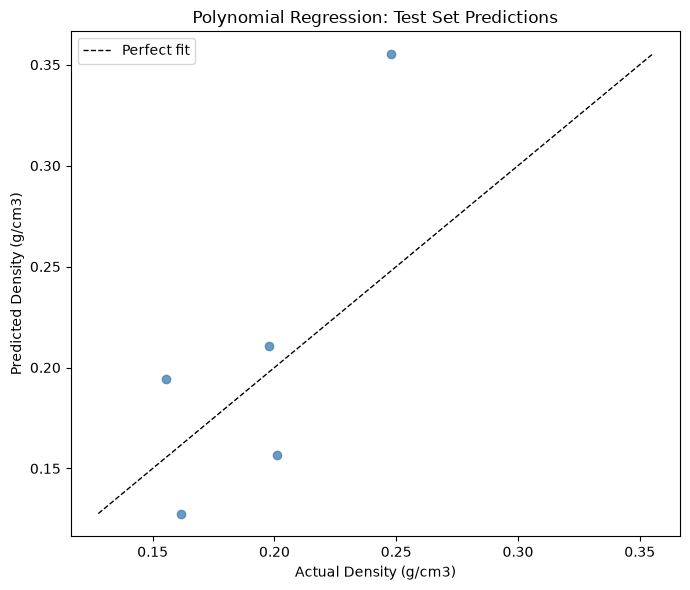

In [9]:
# create polynomial regression model using the train_df and evaluate using R^2 and MAE on the test_df
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_degree = 2
model = make_pipeline(
    PolynomialFeatures(degree=polynomial_degree, include_bias=False),
    LinearRegression(),
)

model.fit(train_df[feature_cols], train_df[target_col])
predicted = model.predict(test_df[feature_cols])

mae = mean_absolute_error(test_df[target_col], predicted)
r2 = r2_score(test_df[target_col], predicted)

comparison_df = test_df.copy()
comparison_df['predicted_density'] = predicted
comparison_df['absolute_error'] = (
    comparison_df[target_col] - comparison_df['predicted_density']
).abs()

print('Test set predictions:')
print(comparison_df.round(6).to_string(index=False))
print(f'\nPolynomial degree: {polynomial_degree}')
print(f'MAE: {mae:.6f}')
print(f'R^2: {r2:.6f}')

actual = test_df[target_col].to_numpy()
min_value = min(actual.min(), predicted.min())
max_value = max(actual.max(), predicted.max())

plt.figure(figsize=(7, 6))
plt.scatter(actual, predicted, color='steelblue', alpha=0.8)
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='black',
    linestyle='--',
    linewidth=1,
    label='Perfect fit',
)
plt.xlabel('Actual Density (g/cm3)')
plt.ylabel('Predicted Density (g/cm3)')
plt.title('Polynomial Regression: Test Set Predictions')
plt.legend()
plt.tight_layout()

output_dir = project_root / 'reports' / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)
figure_path = output_dir / 'polynomial_test_set_actual_vs_predicted_density.png'
plt.savefig(figure_path, dpi=300)
print(f'\nFigure saved to: {figure_path}')
plt.show()